**Table of contents**<a id='toc0_'></a>    
- 1. [Read and clean data](#toc1_)    
  - 1.1. [Checking the scope of compromise with balancing](#toc1_1_)    
- 2. [Some descriptive statistics](#toc2_)    
- 3. [Simple Panel Regression](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# PWT dataproject

In this project we will explore aggregate data from PWT from national accounts. The project is inspired by Mathias BA project which aims to estimate the elasticity of substitution between capital and labour. The project focuses on simple data manipulation and cleaning techniques along with descriptive statistics and statistical modelling. Importantly the mathematics behind estimation-equations are left out since it is not the focus of the project. 

The data includes homogenous collected, thus comparable, data on aggregate variables, from 1950-2019 for 183 countries. 

In [11]:
# imports
from urllib.request import urlretrieve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib_venn import venn2

# statistical modelling packages
import statsmodels 
from linearmodels import PanelOLS

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Countries as con # contains country groups, OECD, IMF Advanced economies, IMF Emerging economies

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. <a id='toc1_'></a>[Read and clean data](#toc0_)

Below we read the data using an API.

In [12]:
# URL of the stata file
url = "https://dataverse.nl/api/access/datafile/354098"

# Read the stata file into a DataFrame
pwt_csv = pd.read_stata(url)

print(f'There are {len(pwt_csv.countrycode.unique())} unique countries in the dataframe')

There are 183 unique countries in the dataframe


For ease of writing and understanding some variables are renamed. The variables hc is a human capital index, and labsh is the labor share of compensation. The dataframe is filtered to remove all unessecary data. 

In [13]:
# rename variables to well-known economic variables
pwt_csv = pwt_csv.rename(columns = {'rgdpna':'Y', "rnna":"K", "emp": "L"})

# filter the df for the variables of interest
var_of_int = ["countrycode","country", "year", "Y", "K", "L", "hc", "labsh"]

# remove all variables not in var_of_int
pwt_csv = pwt_csv[var_of_int]

We now clean the data from missing values, though there are few at this point since missing data is simply omitted from the set from PWT's side. We also generate some new variables which are of interest. 

In [14]:
# drop nan and reset index
pwt_csv.dropna(inplace=True)
pwt_csv.reset_index(inplace=True, drop=True) 

# Generate variables of interest
pwt_csv["cap_out"] = pwt_csv["K"] / pwt_csv["Y"] # capital output ratio
pwt_csv["HC"] = pwt_csv["hc"] * pwt_csv["L"] # aggregate human capital
pwt_csv["capsh"] = 1 - pwt_csv["labsh"] # capital share as reciproc of labsh

# log transform
pwt_csv["lnY"] = np.log(pwt_csv["Y"])
pwt_csv["lnK"] = np.log(pwt_csv["K"])
pwt_csv["ln_capsh"] = np.log(pwt_csv["capsh"])
pwt_csv["ln_labsh"] = np.log(pwt_csv["labsh"])
pwt_csv["ln_cap_out"] = np.log(pwt_csv["K"] / pwt_csv["Y"])
pwt_csv["ln_cap_out_neg"] = -np.log(pwt_csv["K"] / pwt_csv["Y"])

# Sort values by countrycode and year to make functions possible
pwt_csv.sort_values(by=["countrycode", "year"])

,countrycode,country,year,Y,K,L,hc,labsh,cap_out,HC,capsh,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
0,AGO,Angola,1970,54237.054688,257238.093750,3.666207,1.015686,0.284385,4.742848,3.723715,0.715615,10.901119,12.457757,-0.334612,-1.257427,1.556638,-1.556638
1,AGO,Angola,1971,57491.277344,274282.500000,3.742484,1.018196,0.284385,4.770854,3.810581,0.715615,10.959389,12.521914,-0.334612,-1.257427,1.562525,-1.562525
2,AGO,Angola,1972,57606.261719,290921.906250,3.853271,1.020712,0.284385,5.050179,3.933079,0.715615,10.961387,12.580811,-0.334612,-1.257427,1.619424,-1.619424
3,AGO,Angola,1973,62272.367188,309321.281250,3.987807,1.023234,0.284385,4.967232,4.080459,0.715615,11.039273,12.642136,-0.334612,-1.257427,1.602863,-1.602863
4,AGO,Angola,1974,64202.808594,328087.000000,4.130696,1.025762,0.284385,5.110166,4.237112,0.715615,11.069802,12.701035,-0.334612,-1.257427,1.631232,-1.631232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6809,ZWE,Zimbabwe,2015,42008.199219,53550.226562,6.393752,2.584653,0.533381,1.274757,16.525631,0.466619,10.645620,10.888375,-0.762242,-0.628519,0.242755,-0.242755
6810,ZWE,Zimbabwe,2016,42325.726562,55167.007812,6.504374,2.616257,0.533381,1.303392,17.017117,0.466619,10.653151,10.918120,-0.762242,-0.628519,0.264970,-0.264970
6811,ZWE,Zimbabwe,2017,44316.742188,56829.140625,6.611773,2.648248,0.533381,1.282340,17.509615,0.466619,10.699118,10.947804,-0.762242,-0.628519,0.248687,-0.248687
6812,ZWE,Zimbabwe,2018,46457.097656,58552.808594,6.714952,2.680630,0.533381,1.260363,18.000299,0.466619,10.746284,10.977684,-0.762242,-0.628519,0.231400,-0.231400


Importing FD index database and merging with PWT

In [15]:
df2 = pd.read_excel("data/FD Index Database (Excel).xlsx")
df2 = df2[['country','year','FD','FID','FMD']]
df2
merged_df = pd.merge(df2, pwt_csv, how='left', on=['country', 'year'])

Merged dataframe has the same number of rows as the left dataframe in the merge, meaning the 'left-join' worked as expected.

In [16]:
# Function to categorize countries
def categorize_country(countrycode):
    countrycode = countrycode
    if countrycode in con.oecd_countries:
        return 'OECD'
    elif countrycode in con.imf_advanced_countries:
        return 'IMF Advanced'
    elif countrycode in con.imf_emerging_countries:
        return 'IMF Emerging'
    else:
        return 'Other'

# Create a new column in the DataFrame with the category
merged_df['country_category'] = merged_df['countrycode'].apply(categorize_country)

# Drop na 
merged_df = merged_df.dropna()

## Otto

In [17]:
# Group by 'country' and count the number of observations
country_counts = merged_df['country'].value_counts()

# Filter out countries with less than 40 observations
countries_with_40_or_more_observations = country_counts[country_counts >= 40].index

# Filter the original DataFrame based on the selected countries
filtered_df = merged_df[merged_df['country'].isin(countries_with_40_or_more_observations)]

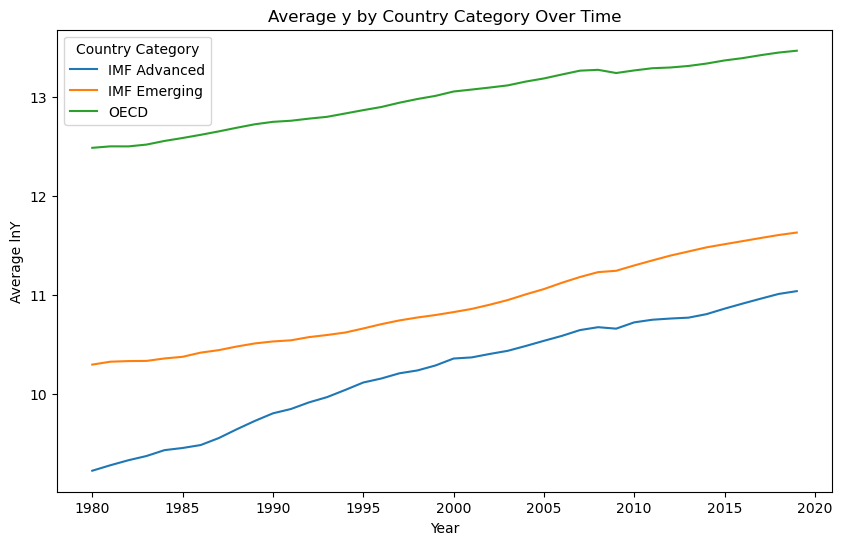

In [19]:
# Calculate the mean ratio for each year
avg_y = filtered_df.groupby(['year', 'country_category'])['lnY'].mean().unstack()

# Plotting
avg_y.plot(figsize=(10, 6))

# Adding labels and title
plt.title('Average y by Country Category Over Time')
plt.xlabel('Year')
plt.ylabel('Average lnY')

# Adding legend
plt.legend(title='Country Category')

# Show plot
plt.show()

In [20]:
nan_count_per_column = filtered_df.isna().sum()
print("Number of NaN values in each column:")
print(nan_count_per_column)

Number of NaN values in each column:
country             0
year                0
FD                  0
FID                 0
FMD                 0
countrycode         0
Y                   0
K                   0
L                   0
hc                  0
labsh               0
cap_out             0
HC                  0
capsh               0
lnY                 0
lnK                 0
ln_capsh            0
ln_labsh            0
ln_cap_out          0
ln_cap_out_neg      0
country_category    0
dtype: int64


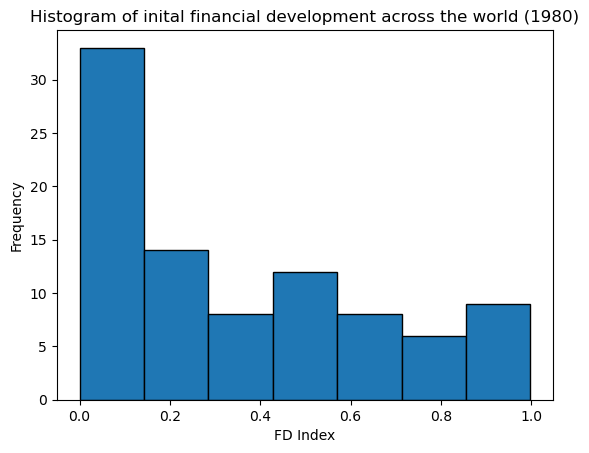

In [21]:
initial_ratios = filtered_df.groupby('country')['FMD'].first().reset_index()
plt.hist(initial_ratios['FMD'], bins=7, edgecolor='black')
plt.title('Histogram of inital financial development across the world (1980)')
plt.xlabel('FD Index')
plt.ylabel('Frequency')
plt.show()

In [22]:
# Define categories based on the initial ratio
bins = np.linspace(0, 1, num=4)
labels = ['Lav FD lande', 'Mellem FD lande', 'Høj FD lande']

# Create a new column for the categories
initial_ratios['FD_Category'] = pd.cut(initial_ratios['FMD'], bins=bins, labels=labels, right=False)

# Merge the categories back into the main DataFrame
categorized_df = pd.merge(filtered_df, initial_ratios[['country', 'FD_Category']], on='country', how='left')
categorized_df

,country,year,FD,FID,FMD,countrycode,Y,K,L,hc,...,HC,capsh,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,24.667574,0.668858,12.311113,14.078606,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,23.709661,0.668858,12.326253,14.071785,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,22.808849,0.653629,12.346493,14.063895,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,21.942038,0.656975,12.347968,14.052345,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,21.107916,0.650872,12.374104,14.025472,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,3.280004,0.554279,9.609313,12.141117,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande
3596,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,3.136179,0.554279,9.615176,12.162943,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande
3597,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,3.027187,0.554279,9.586166,12.182692,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande
3598,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,2.897379,0.554279,9.561687,12.197562,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande


c:\Users\mathi\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


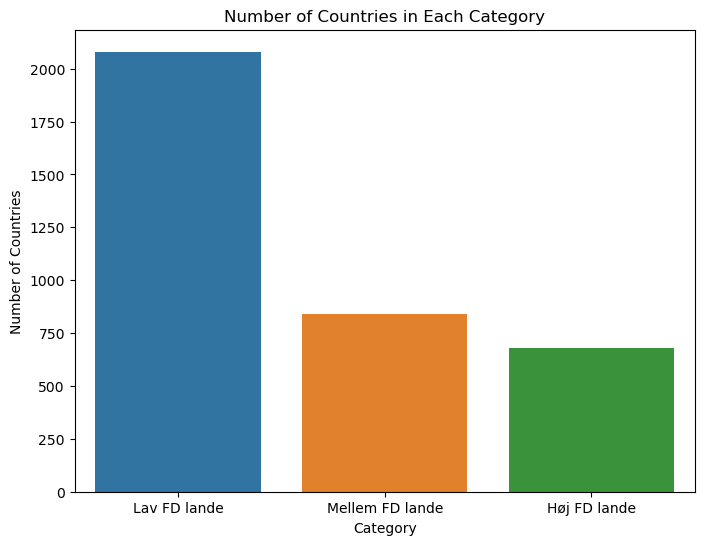

In [23]:
# Assuming 'FD_Category' is the column containing the categories
category_counts = categorized_df['FD_Category'].value_counts()

# Plotting the number of countries in each category
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Number of Countries in Each Category')
plt.xlabel('Category')
plt.ylabel('Number of Countries')
plt.show()

C:\Users\mathi\AppData\Local\Temp\ipykernel_14808\70625028.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_y = categorized_df.groupby(['year', 'FD_Category'])['K'].mean().unstack()
C:\Users\mathi\AppData\Local\Temp\ipykernel_14808\70625028.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_FID = categorized_df.groupby(['year', 'FD_Category'])['FMD'].mean().unstack()


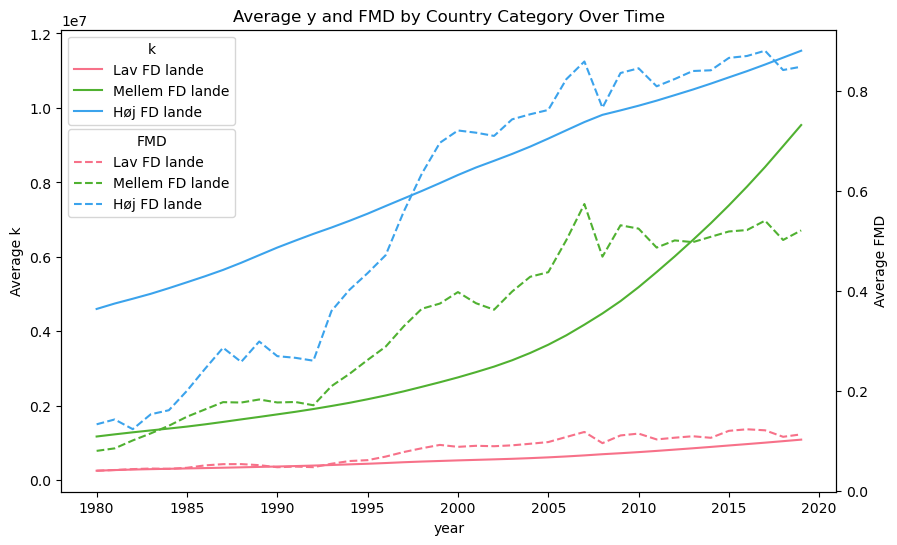

In [26]:
# Define custom color palette
custom_palette = sns.color_palette("husl", n_colors=len(avg_y.columns))

# Calculate the mean ratio for each year
avg_y = categorized_df.groupby(['year', 'FD_Category'])['K'].mean().unstack()
avg_FID = categorized_df.groupby(['year', 'FD_Category'])['FMD'].mean().unstack()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot avg_y on primary axis
avg_y.plot(ax=ax1, color=custom_palette)
ax1.set_ylabel('Average k')

# Creating secondary axis
ax2 = ax1.twinx()

# Plot avg_FID on secondary axis
avg_FID.plot(ax=ax2, linestyle='--', color=custom_palette)
ax2.set_ylabel('Average FMD')

# Adding labels and title
plt.title('Average y and FMD by Country Category Over Time')
plt.xlabel('Year')

# Adding legend
legend1 = ax1.legend(title='k', loc='upper left', bbox_to_anchor=(0, 1))
legend2 = ax2.legend(title='FMD', loc='upper left', bbox_to_anchor=(0, 0.8))


# Show plot
plt.show()



In [27]:
""" 
Alternative categorization using KNearestneighbors.
"""
categorized_df['code']= pd.factorize(categorized_df['country'])[0]+1


dfA = categorized_df[['code','FD','FID','FMD','hc','lnY','ln_capsh']]

initial_ratio_df = dfA.groupby('code').first().reset_index()

In [28]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(initial_ratio_df)

# statistics of scaled data
pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6
count,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01
mean,1.480297e-17,-5.057683e-17,1.233581e-17,-6.167906e-18,1.884295e-16,-4.564250e-17,1.147230e-16
std,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00
min,-1.712912e+00,-1.567098e+00,-1.208780e+00,-1.121694e+00,-2.198240e+00,-2.147210e+00,-3.518511e+00
25%,-8.564558e-01,-9.250912e-01,-8.361270e-01,-9.151541e-01,-6.795676e-01,-8.750055e-01,-5.394981e-01
50%,0.000000e+00,-1.261145e-01,-4.229279e-01,-3.334379e-01,1.087506e-01,5.367174e-02,-2.246098e-02
75%,8.564558e-01,8.861540e-01,9.125345e-01,7.411106e-01,6.833190e-01,7.019743e-01,6.390706e-01
max,1.712912e+00,2.059736e+00,2.071285e+00,2.097018e+00,2.319758e+00,2.393955e+00,2.222287e+00


In [31]:
# defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=100)

# fitting the k means algorithm on scaled data
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)
# inertia on the fitted data
kmeans.inertia_
unique, counts = np.unique(pred, return_counts=True)

c:\Users\mathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [32]:
unique, counts

(array([0, 1, 2]), array([23, 39, 28], dtype=int64))

In [33]:
initial_ratio_df['Kmeans_label'] = kmeans.labels_

In [34]:
categorized_df

,country,year,FD,FID,FMD,countrycode,Y,K,L,hc,...,capsh,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category,code
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,0.668858,12.311113,14.078606,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande,1
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,0.668858,12.326253,14.071785,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande,1
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,0.653629,12.346493,14.063895,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande,1
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,0.656975,12.347968,14.052345,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande,1
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,0.650872,12.374104,14.025472,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,0.554279,9.609313,12.141117,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande,90
3596,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,0.554279,9.615176,12.162943,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande,90
3597,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,0.554279,9.586166,12.182692,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande,90
3598,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,0.554279,9.561687,12.197562,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande,90


In [35]:
categorized_df_final = pd.merge(categorized_df,initial_ratio_df[['code','Kmeans_label']], how='left', on='code')
categorized_df_final

,country,year,FD,FID,FMD,countrycode,Y,K,L,hc,...,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category,code,Kmeans_label
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,12.311113,14.078606,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande,1,0
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,12.326253,14.071785,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande,1,0
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,12.346493,14.063895,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande,1,0
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,12.347968,14.052345,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande,1,0
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,12.374104,14.025472,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,9.609313,12.141117,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande,90,1
3596,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,9.615176,12.162943,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande,90,1
3597,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,9.586166,12.182692,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande,90,1
3598,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,9.561687,12.197562,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande,90,1


In [36]:
klabels = categorized_df_final['Kmeans_label'].unique()
country_bins = []
year_slice = categorized_df_final[categorized_df_final['year']==2000]

for label in klabels:
    temp = year_slice[year_slice['Kmeans_label']==label]
    temp = temp['country'].reset_index()
    temp = temp.rename(columns={'country':f'Group: {label}'})
    country_bins.append(temp)

category_df = pd.concat(country_bins, axis=1)
category_df = category_df[['Group: 0','Group: 1','Group: 2',]]

In [37]:
category_df

,Group: 0,Group: 1,Group: 2
0,Angola,Argentina,Australia
1,Burundi,Bulgaria,Austria
2,Benin,Bahrain,Belgium
3,Burkina Faso,Botswana,Brazil
4,Barbados,Colombia,Canada
5,Central African Republic,Costa Rica,Switzerland
6,Cameroon,Cyprus,Chile
7,Ecuador,Dominican Republic,China
8,Fiji,Gabon,Germany
9,Guatemala,Greece,Denmark


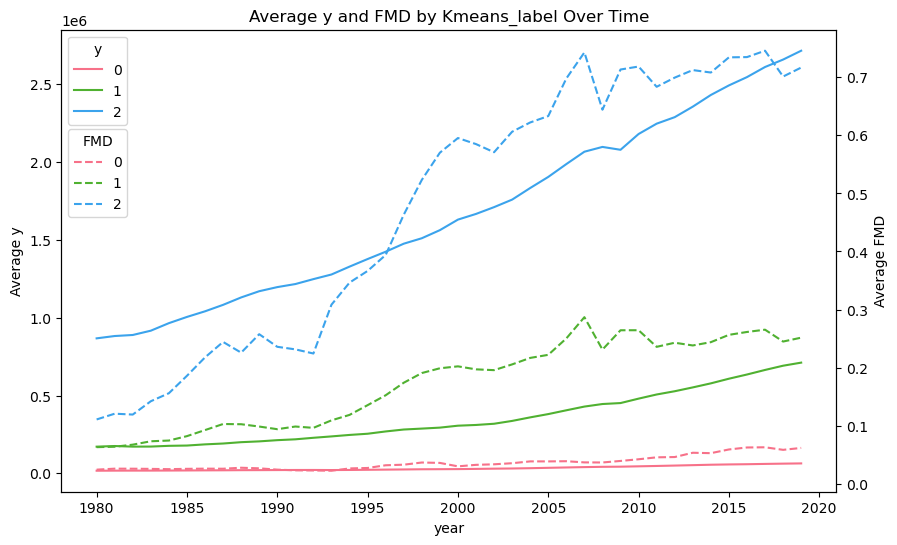

In [40]:
# Calculate the mean ratio for each year
avg_y2 = categorized_df_final.groupby(['year', 'Kmeans_label'])['Y'].mean().unstack()
avg_k2 = categorized_df_final.groupby(['year', 'Kmeans_label'])['FMD'].mean().unstack()

# Define custom color palette
custom_palette = sns.color_palette("husl", n_colors=len(avg_y2.columns))
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot avg_y on primary axis
avg_y2.plot(ax=ax1, color=custom_palette)
ax1.set_ylabel('Average y')

# Creating secondary axis
ax2 = ax1.twinx()

# Plot avg_FID on secondary axis
avg_k2.plot(ax=ax2, linestyle='--', color=custom_palette)
ax2.set_ylabel('Average FMD')

# Adding labels and title
plt.title('Average y and FMD by Kmeans_label Over Time')
plt.xlabel('Year')

# Adding legend
legend1 = ax1.legend(title='y', loc='upper left', bbox_to_anchor=(0, 1))
legend2 = ax2.legend(title='FMD', loc='upper left', bbox_to_anchor=(0, 0.8))


# Show plot
plt.show()



We now clean the data from missing values, though there are few at this point since missing data is simply omitted from the set from PWT's side. We also generate some new variables which are of interest. 

In [41]:
# drop nan and reset index
pwt_csv.dropna(inplace=True)
pwt_csv.reset_index(inplace=True, drop=True) 

# Generate variables of interest
pwt_csv["cap_out"] = pwt_csv["K"] / pwt_csv["Y"] # capital output ratio
pwt_csv["HC"] = pwt_csv["hc"] * pwt_csv["L"] # aggregate human capital
pwt_csv["capsh"] = 1 - pwt_csv["labsh"] # capital share as reciproc of labsh

# log transform
pwt_csv["lnY"] = np.log(pwt_csv["Y"])
pwt_csv["lnK"] = np.log(pwt_csv["K"])
pwt_csv["ln_capsh"] = np.log(pwt_csv["capsh"])
pwt_csv["ln_labsh"] = np.log(pwt_csv["labsh"])
pwt_csv["ln_cap_out"] = np.log(pwt_csv["K"] / pwt_csv["Y"])
pwt_csv["ln_cap_out_neg"] = -np.log(pwt_csv["K"] / pwt_csv["Y"])

# Sort values by countrycode and year to make functions possible
pwt_csv.sort_values(by=["countrycode", "year"])

,countrycode,country,year,Y,K,L,hc,labsh,cap_out,HC,capsh,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
0,AGO,Angola,1970,54237.054688,257238.093750,3.666207,1.015686,0.284385,4.742848,3.723715,0.715615,10.901119,12.457757,-0.334612,-1.257427,1.556638,-1.556638
1,AGO,Angola,1971,57491.277344,274282.500000,3.742484,1.018196,0.284385,4.770854,3.810581,0.715615,10.959389,12.521914,-0.334612,-1.257427,1.562525,-1.562525
2,AGO,Angola,1972,57606.261719,290921.906250,3.853271,1.020712,0.284385,5.050179,3.933079,0.715615,10.961387,12.580811,-0.334612,-1.257427,1.619424,-1.619424
3,AGO,Angola,1973,62272.367188,309321.281250,3.987807,1.023234,0.284385,4.967232,4.080459,0.715615,11.039273,12.642136,-0.334612,-1.257427,1.602863,-1.602863
4,AGO,Angola,1974,64202.808594,328087.000000,4.130696,1.025762,0.284385,5.110166,4.237112,0.715615,11.069802,12.701035,-0.334612,-1.257427,1.631232,-1.631232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6809,ZWE,Zimbabwe,2015,42008.199219,53550.226562,6.393752,2.584653,0.533381,1.274757,16.525631,0.466619,10.645620,10.888375,-0.762242,-0.628519,0.242755,-0.242755
6810,ZWE,Zimbabwe,2016,42325.726562,55167.007812,6.504374,2.616257,0.533381,1.303392,17.017117,0.466619,10.653151,10.918120,-0.762242,-0.628519,0.264970,-0.264970
6811,ZWE,Zimbabwe,2017,44316.742188,56829.140625,6.611773,2.648248,0.533381,1.282340,17.509615,0.466619,10.699118,10.947804,-0.762242,-0.628519,0.248687,-0.248687
6812,ZWE,Zimbabwe,2018,46457.097656,58552.808594,6.714952,2.680630,0.533381,1.260363,18.000299,0.466619,10.746284,10.977684,-0.762242,-0.628519,0.231400,-0.231400


## Subsetting and balancing panel data 

Untill know we have worked with the entire country sample from PWT, we know generate new datasets containing only countries in certain international economic institutions, OECD, IMF. These groups are specified in the countries.py file.  

In [42]:
# List of the 4 groups of interest
# entire set
world_data = pwt_csv.copy()

# Define new dataframes as the country groups in the py-file
oecd_data = pwt_csv[pwt_csv['countrycode'].isin(con.oecd_countries)]
imf_advanced_data = pwt_csv[pwt_csv['countrycode'].isin(con.imf_advanced_countries)]
imf_emerging_data = pwt_csv[pwt_csv['countrycode'].isin(con.imf_emerging_countries)]

When working with panel data it is important to be aware of the dataset structure. We refer to a panel as being either balanced or unbalanced. In regression, this is important since it can require different methods and yield different results. To simplify, we make the entire panel balanced from 1960 (could possible find a nice way to determine a balance between amount of countries and years?)

In [43]:
# Make them balanced  
# Group by country code and find the minimum year for each country
min_years_by_country = pwt_csv.groupby('countrycode')['year'].min()

# Decide that 1960 is the latest allowed starting point
# Delete all countries where starting year is above 1960 

# Filter out countries where the starting year is after 1960
countries_before_1960 = min_years_by_country[min_years_by_country <= 1960].index

# Filter the DataFrame to include only countries with starting year before or in 1960
balanced_data = pwt_csv[pwt_csv['countrycode'].isin(countries_before_1960)]

# Filter out all observations before 1960 
balanced_data = balanced_data[balanced_data['year'] > 1959]

# Filtering the data into the 4 groups 
world_bal_data = balanced_data.copy()
oecd_bal_data = balanced_data[balanced_data['countrycode'].isin(con.oecd_countries)]
imf_advanced_bal_data = balanced_data[balanced_data['countrycode'].isin(con.imf_advanced_countries)]
imf_emerging_bal_data = balanced_data[balanced_data['countrycode'].isin(con.imf_emerging_countries)]


To check whether the restriction in using 1960 as the cutoff year for balancing was reasonable, we are interested in seing how many countries were omitted. 

In [44]:
# How many countries are removed 
num_countries_before = len(pwt_csv['countrycode'].unique())
num_countries_after = len(balanced_data['countrycode'].unique())

# Define functions to calculate the number of countries in each group
def num_countries_in_group(group_name, country_list):
    return len(pwt_csv[pwt_csv['countrycode'].isin(country_list)]['countrycode'].unique())

def num_countries_in_group_after_filter(group_name, country_list):
    return len(balanced_data[balanced_data['countrycode'].isin(country_list)]['countrycode'].unique())

# Calculate the number of countries in each group before filtering
num_countries_in_groups_before = {
    "world": num_countries_in_group("world", pwt_csv['countrycode'].unique()),
    "oecd": num_countries_in_group("oecd", con.oecd_countries),
    "imf_advanced": num_countries_in_group("imf_advanced", con.imf_advanced_countries),
    "imf_emerging": num_countries_in_group("imf_emerging", con.imf_emerging_countries)
}

# Calculate the number of countries in each group after filtering
num_countries_in_groups_after = {
    "world": num_countries_in_group_after_filter("world", pwt_csv['countrycode'].unique()),
    "oecd": num_countries_in_group_after_filter("oecd", con.oecd_countries),
    "imf_advanced": num_countries_in_group_after_filter("imf_advanced", con.imf_advanced_countries),
    "imf_emerging": num_countries_in_group_after_filter("imf_emerging", con.imf_emerging_countries)
}

# Calculate the number of countries removed from each group
num_countries_removed_from_groups = {
    group: num_countries_in_groups_before[group] - num_countries_in_groups_after[group]
    for group in num_countries_in_groups_before
}

# Print the results
for group, num_removed in num_countries_removed_from_groups.items():
    print(f"Number of countries removed from {group} group: {num_removed}")

Number of countries removed from world group: 40
Number of countries removed from oecd group: 8
Number of countries removed from imf_advanced group: 8
Number of countries removed from imf_emerging group: 32


## 2. <a id='toc2_'></a>[Some descriptive statistics](#toc0_)

Could do some interactive plots on capital output relationship or capital labor shares, differences between countries or group averages. 

In [45]:
pwt_csv['g_K'] = pwt_csv['K'].pct_change(periods=1)*100
pwt_csv['g_Y'] = pwt_csv['Y'].pct_change(periods=1)*100

In [46]:
pwt_csv_grouped = pwt_csv.groupby(by=["countrycode"])

## 3. <a id='toc3_'></a>[Simple Panel Regression](#toc0_)


Estimating the EOS between capital and labour, $\sigma$, defined as $\sigma=\frac{1}{1+\phi}$, from the following equation $\ln(\frac{rK}{Y})_{it} = c_i+d_t-\phi\ln(\frac{K}{Y})_{it}+\epsilon_{it}$, which follows from a CES production function, using the first order condition an algebraic manipulation. These variables are naturally stationary, such that the FE estimator is consistent and unbiased. 

We include fixed effects to capture the unobserved characteristics of countries, i.e. any factors that are constant over time for each individual but different across countries. This could be differences in institutions, culture, natural ressources. 

We include time effects to similarly capture the unobserved factors that affect all countries in the panel simultanously across time periods. This could be macroeconomic conditions such as global economic cycles, technological changes or policy shifts.  

In [47]:
def fixed_effects(data, fixed_effects, time_effects):
    data = data.set_index(["countrycode", "year"])
    a = data["ln_capsh"]
    cap_out = data["ln_cap_out_neg"]
    
    res = PanelOLS(a, cap_out, entity_effects=fixed_effects, time_effects=time_effects).fit(cov_type="clustered", cluster_entity=True)
    sigma = 1/(1+res.params)
    return sigma

print("oecd results")
print(fixed_effects(oecd_data, True, True))


oecd results
ln_cap_out_neg    0.951513
Name: parameter, dtype: float64
